In [1]:
import torch
import tensorflow as tf

print("=== PyTorch ===")
print(f"Versión: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Operación real en GPU
x = torch.rand(1000, 1000).cuda()
y = torch.rand(1000, 1000).cuda()
z = x @ y
print(f"Tensor en: {z.device} ✅")

print("\n=== TensorFlow ===")
print(f"Versión: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

# Operación real en GPU
with tf.device('/GPU:0'):
    a = tf.random.normal([1000, 1000])
    b = tf.random.normal([1000, 1000])
    c = tf.matmul(a, b)
print(f"TF operación en GPU completada ✅")

print("\n✅ Todo funcionando con GPU")

I0000 00:00:1778193340.119317   48622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778193340.738307   48622 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778193343.778356   48622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


=== PyTorch ===
Versión: 2.12.0.dev20260407+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Tensor en: cuda:0 ✅

=== TensorFlow ===
Versión: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1778193347.854996   48622 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778193347.866783   48622 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778193347.881503   48622 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5198 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


TF operación en GPU completada ✅

✅ Todo funcionando con GPU


# **Bloque 1: Segmentación de imágenes**

## **Librerías**

Se importan las librerías necesarias para ejecutar el proyecto.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
import pickle
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch

/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **1. Carga de datos**

Se definen las rutas al datset.

In [3]:
BASE_PATH  = r"/home/moon/DEEP/MP3/data"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
CSV_PATH   = os.path.join(BASE_PATH, "train.csv")

In [4]:
print(f"Cantidades de imágenes: {len(os.listdir(TRAIN_PATH))}")

Cantidades de imágenes: 606


Se carga el archivo de anotaciones `train.csv`, el cual contiene una fila por cada **célula individual** detectada. 

In [5]:
df = pd.read_csv(CSV_PATH)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73585 entries, 0 to 73584
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 73585 non-null  str  
 1   annotation         73585 non-null  str  
 2   width              73585 non-null  int64
 3   height             73585 non-null  int64
 4   cell_type          73585 non-null  str  
 5   plate_time         73585 non-null  str  
 6   sample_date        73585 non-null  str  
 7   sample_id          73585 non-null  str  
 8   elapsed_timedelta  73585 non-null  str  
dtypes: int64(2), str(7)
memory usage: 5.1 MB


In [7]:
df.head()

,id,annotation,width,height,cell_type,plate_time,sample_date,sample_id,elapsed_timedelta
0,0030fd0e6378,118145 6 118849 7 119553 8 120257 8 120961 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
1,0030fd0e6378,189036 1 189739 3 190441 6 191144 7 191848 8 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
2,0030fd0e6378,173567 3 174270 5 174974 5 175678 6 176382 7 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
3,0030fd0e6378,196723 4 197427 6 198130 7 198834 8 199538 8 2...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00
4,0030fd0e6378,167818 3 168522 5 169225 7 169928 8 170632 9 1...,704,520,shsy5y,11h30m00s,2019-06-16,shsy5y[diff]_E10-4_Vessel-714_Ph_3,0 days 11:30:00


El dataset contiene 73,585 filas que representan células individuales anotadas, distribuidas en 606 imágenes únicas. Tiene 9 columnas entre estas id, annotation, width, height, cell_type e incluye metadatos experimentales como plate_time, sample_date, sample_id y elapsed_timedelta, que registran condiciones del experimento microscópico. No hay valores nulos en ninguna columna. Cada fila comparte el mismo id con otras filas de la misma imagen, confirmando que una imagen puede contener múltiples células anotadas individualmente en formato RLE.

## **2. Construcción de dataset estructurado**

Se agrupan las máscaras de cada imagen en una sola fila para obtener 
una vista resumida a nivel de imagen. Esto permite analizar características globales como el número de células por imagen y el área de cada máscara.

In [8]:
def rle_decode(mask_rle, shape):
    s       = mask_rle.split()
    starts  = np.array(s[0::2], dtype=int) - 1
    lengths = np.array(s[1::2], dtype=int)
    ends    = starts + lengths
    img     = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape, order='C')

In [9]:
df['area'] = df.apply(
    lambda row: rle_decode(row['annotation'], (row['height'], row['width'])).sum(),
    axis=1
)

In [10]:
df_grouped = df.groupby('id').agg(
    num_masks    = ('annotation', 'count'),
    cell_type    = ('cell_type', 'first'),
    image_width  = ('width', 'first'),
    image_height = ('height', 'first'),
    area_total   = ('area', 'sum'),
    area_mean    = ('area', 'mean'),
    area_max     = ('area', 'max'),
    area_min     = ('area', 'min'),
).reset_index()

df_grouped['ruta_imagen'] = df_grouped['id'].apply(
    lambda x: os.path.join(TRAIN_PATH, f"{x}.png")
)

In [11]:
print(f"Total imágenes únicas : {len(df_grouped)}")
print(f"\nTipos celulares:\n{df['cell_type'].value_counts()}")
print(f"\nEstadísticas de máscaras por imagen:")
print(df_grouped['num_masks'].describe())
print(f"\nEstadísticas de área por máscara (píxeles):")
print(df['area'].describe())

Total imágenes únicas : 606

Tipos celulares:
cell_type
shsy5y    52286
cort      10777
astro     10522
Name: count, dtype: int64

Estadísticas de máscaras por imagen:
count    606.000000
mean     121.427393
std      152.001676
min        4.000000
25%       28.000000
50%       46.000000
75%      140.250000
max      790.000000
Name: num_masks, dtype: float64

Estadísticas de área por máscara (píxeles):
count    73585.000000
mean       324.212217
std        420.259531
min         30.000000
25%        145.000000
50%        215.000000
75%        340.000000
max      13327.000000
Name: area, dtype: float64


El dataset contiene 606 imágenes únicas con un total de 73,585 células anotadas. En cuanto a los tipos celulares, existe un desbalance notable: `shsy5y` domina ampliamente con 52,286 instancias (71%), mientras que `cort` y `astro` presentan frecuencias similares y significativamente menores, con 10,777 y 10,522 instancias respectivamente. Respecto al número de células por imagen, el promedio es de 121 células, pero la alta desviación estándar (152) junto con un rango que va de 4 a 790 indican una variabilidad extrema entre imágenes. El 50% de las imágenes contiene menos de 46 células, lo que sugiere que la distribución está sesgada hacia la derecha por un grupo reducido de imágenes muy densamente pobladas. En cuanto al área de las máscaras individuales, las células son en general pequeñas: la mediana es de apenas 215 píxeles, con un máximo de 13,327, lo que evidencia también una alta variabilidad en el tamaño celular dentro del dataset.

In [12]:
df_grouped.head()

,id,num_masks,cell_type,image_width,image_height,area_total,area_mean,area_max,area_min,ruta_imagen
0,0030fd0e6378,395,shsy5y,704,520,113307,286.853165,757,46,/home/moon/DEEP/MP3/data/train/0030fd0e6378.png
1,0140b3c8f445,108,astro,704,520,86735,803.101852,7126,138,/home/moon/DEEP/MP3/data/train/0140b3c8f445.png
2,01ae5a43a2ab,36,cort,704,520,11382,316.166667,522,149,/home/moon/DEEP/MP3/data/train/01ae5a43a2ab.png
3,026b3c2c4b32,42,cort,704,520,7660,182.380952,355,84,/home/moon/DEEP/MP3/data/train/026b3c2c4b32.png
4,029e5b3b89c7,34,cort,704,520,5753,169.205882,277,107,/home/moon/DEEP/MP3/data/train/029e5b3b89c7.png


## **3. Análisis Exploratorio de Datos (EDA)**

### **3.1. Tamaño de imágenes**

Se analiza la distribución de las dimensiones (alto y ancho) de las imágenes 
del dataset. Esto permite determinar si todas las imágenes tienen el mismo tamaño o si existe variabilidad dimensional, lo cual es relevante para decidir la estrategia de redimensionamiento en el preprocesamiento.

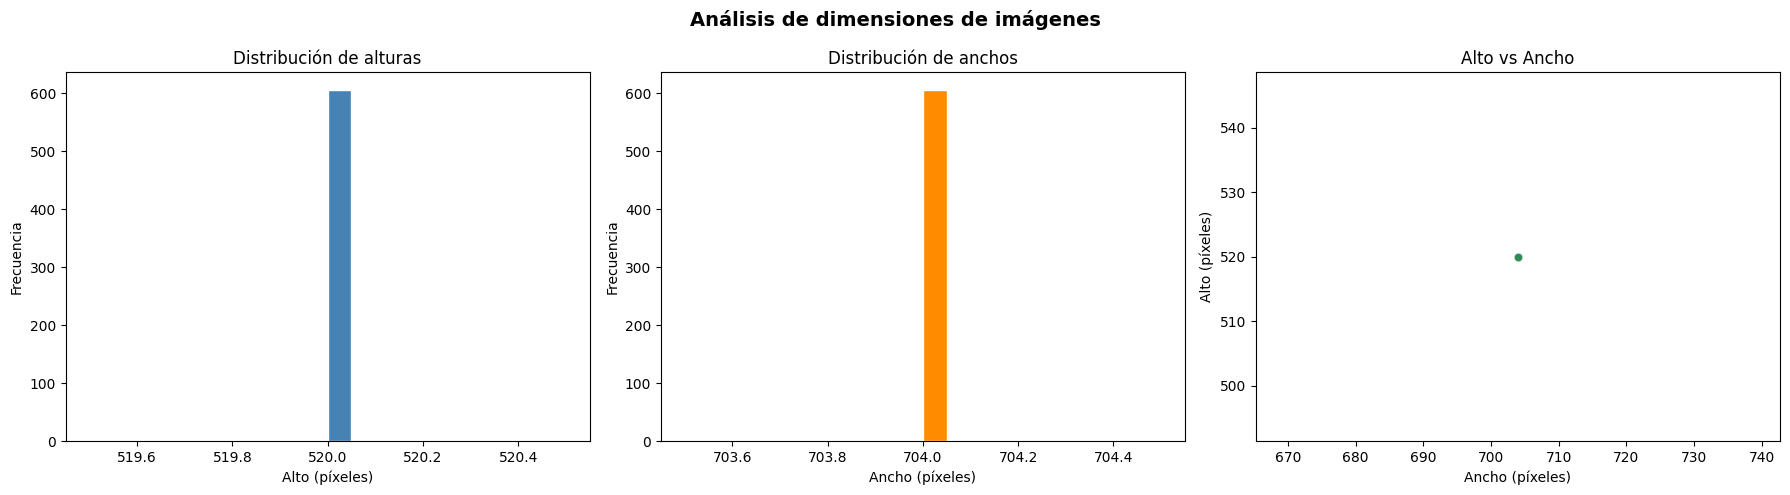

Alturas únicas : [520]
Anchos únicos  : [704]


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de alturas
axes[0].hist(df_grouped['image_height'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de alturas')
axes[0].set_xlabel('Alto (píxeles)')
axes[0].set_ylabel('Frecuencia')

# Histograma de anchos
axes[1].hist(df_grouped['image_width'], bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución de anchos')
axes[1].set_xlabel('Ancho (píxeles)')
axes[1].set_ylabel('Frecuencia')

# Scatter plot alto vs ancho
axes[2].scatter(df_grouped['image_width'], df_grouped['image_height'],
                alpha=0.5, color='seagreen', edgecolors='white', linewidths=0.5)
axes[2].set_title('Alto vs Ancho')
axes[2].set_xlabel('Ancho (píxeles)')
axes[2].set_ylabel('Alto (píxeles)')

plt.suptitle('Análisis de dimensiones de imágenes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Alturas únicas : {df_grouped['image_height'].unique()}")
print(f"Anchos únicos  : {df_grouped['image_width'].unique()}")

Las imágenes del dataset son completamente homogéneas en sus dimensiones: todas tienen exactamente 704 × 520 píxeles, sin ninguna variación. Esto se confirma en los histogramas, que muestran una única barra, y en el scatter plot, que concentra todos los puntos en una sola coordenada.

### **3.2. Número de células por imagen**

Se analiza la distribución del número de instancias celulares por imagen.
Este análisis permite identificar si existe variabilidad en la densidad celular
entre imágenes.

/tmp/ipykernel_48622/857432673.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_box, labels=cell_types, patch_artist=True,


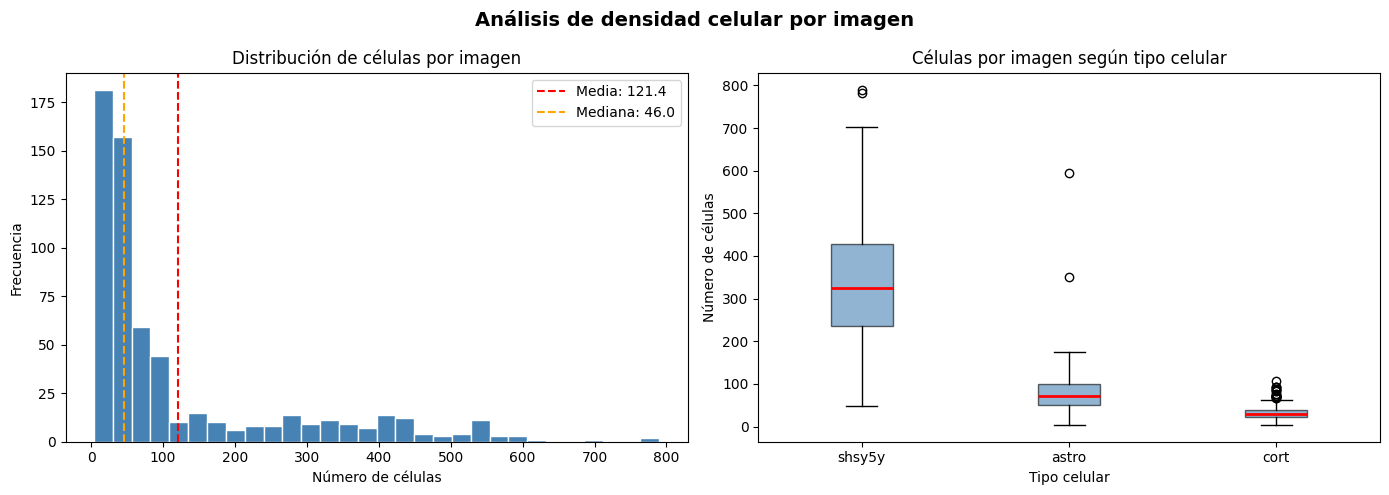

           count    mean     std   min    25%    50%    75%    max
cell_type                                                         
astro      131.0   80.32   64.13   5.0   50.0   73.0  100.0  594.0
cort       320.0   33.68   16.50   4.0   23.0   30.0   39.0  108.0
shsy5y     155.0  337.33  149.60  49.0  235.5  324.0  429.0  790.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_grouped['num_masks'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de células por imagen')
axes[0].set_xlabel('Número de células')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_grouped['num_masks'].mean(), color='red', linestyle='--', 
                label=f"Media: {df_grouped['num_masks'].mean():.1f}")
axes[0].axvline(df_grouped['num_masks'].median(), color='orange', linestyle='--',
                label=f"Mediana: {df_grouped['num_masks'].median():.1f}")
axes[0].legend()

# Boxplot por tipo celular
cell_types = df_grouped['cell_type'].unique()
data_box   = [df_grouped[df_grouped['cell_type'] == ct]['num_masks'].values 
              for ct in cell_types]

axes[1].boxplot(data_box, labels=cell_types, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Células por imagen según tipo celular')
axes[1].set_xlabel('Tipo celular')
axes[1].set_ylabel('Número de células')

plt.suptitle('Análisis de densidad celular por imagen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas por tipo celular
print(df_grouped.groupby('cell_type')['num_masks'].describe().round(2))

La distribución del número de células por imagen es marcadamente asimétrica hacia la derecha, con una mediana de 46 células pero una media de 121, lo que indica que un grupo reducido de imágenes muy densamente pobladas eleva considerablemente el promedio. Al desagregar por tipo celular, las diferencias son sustanciales: las imágenes de `shsy5y` contienen en promedio 337 células (máximo 790), mientras que `astro` promedia 80 y `cort` apenas 34. Esto confirma que el tipo celular determina en gran medida la densidad de instancias por imagen, y que `shsy5y` representa el escenario más complejo para la segmentación por su alta densidad celular. El boxplot de `shsy5y` muestra además varios outliers extremos, lo que añade variabilidad adicional dentro de ese grupo.

### **3.3. Área de células**

Se analiza la distribución del área de cada máscara individual, medida en número de píxeles activos. Este análisis permite determinar si las células son pequeñas o grandes en términos relativos, y si existe variabilidad significativa en su tamaño dentro del dataset.

/tmp/ipykernel_48622/2792024020.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_box, labels=cell_types, patch_artist=True,


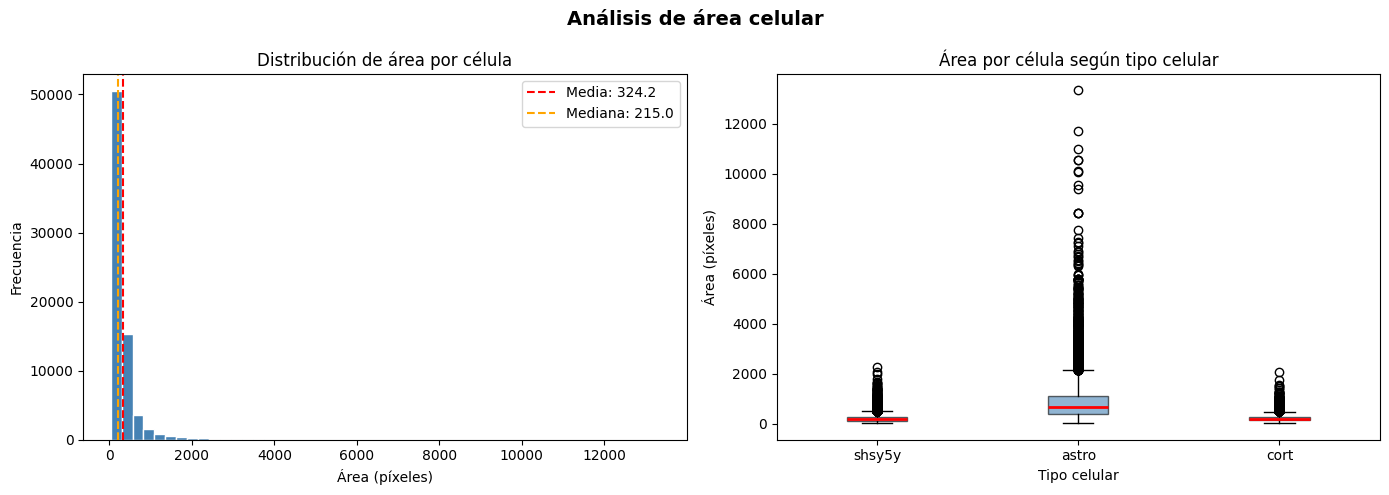

             count    mean     std   min    25%    50%     75%      max
cell_type                                                              
astro      10522.0  905.81  855.19  37.0  407.0  665.0  1098.0  13327.0
cort       10777.0  240.16  139.17  33.0  151.0  208.0   288.0   2054.0
shsy5y     52286.0  224.50  133.94  30.0  133.0  193.0   280.0   2254.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de áreas
axes[0].hist(df['area'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de área por célula')
axes[0].set_xlabel('Área (píxeles)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['area'].mean(), color='red', linestyle='--',
                label=f"Media: {df['area'].mean():.1f}")
axes[0].axvline(df['area'].median(), color='orange', linestyle='--',
                label=f"Mediana: {df['area'].median():.1f}")
axes[0].legend()

# Boxplot por tipo celular
cell_types = df['cell_type'].unique()
data_box   = [df[df['cell_type'] == ct]['area'].values for ct in cell_types]

axes[1].boxplot(data_box, labels=cell_types, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Área por célula según tipo celular')
axes[1].set_xlabel('Tipo celular')
axes[1].set_ylabel('Área (píxeles)')

plt.suptitle('Análisis de área celular', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas por tipo celular
print(df.groupby('cell_type')['area'].describe().round(2))

La distribución del área celular es extremadamente asimétrica hacia la derecha, con la gran mayoría de células concentradas por debajo de los 500 píxeles, una mediana de 215 píxeles y una media de 324. Al desagregar por tipo celular, las diferencias son notables: `astro` presenta las células más grandes, con una media de 906 píxeles y un máximo de 13,327, lo que indica morfologías celulares considerablemente más extensas. En contraste, `shsy5y` y `cort` tienen células mucho más pequeñas y similares entre sí, con medias de 225 y 240 píxeles respectivamente. Los tres tipos muestran una cantidad importante de outliers en el extremo superior, lo que refleja variabilidad morfológica dentro de cada clase. Esta diferencia de escala entre tipos celulares es relevante para el diseño del modelo, ya que deberá ser capaz de segmentar instancias de tamaños muy distintos dentro de una misma imagen.

### **3.4. Intensidad de píxeles**

Se analiza la distribución de los valores de intensidad de los píxeles de las imágenes. Dado que las imágenes microscópicas son en escala de grises, se analiza un único canal. Este análisis permite identificar el rango dinámico de las imágenes, detectar posibles problemas de contraste, sobreexposición o subexposición, y orientar la estrategia de normalización en el preprocesamiento.

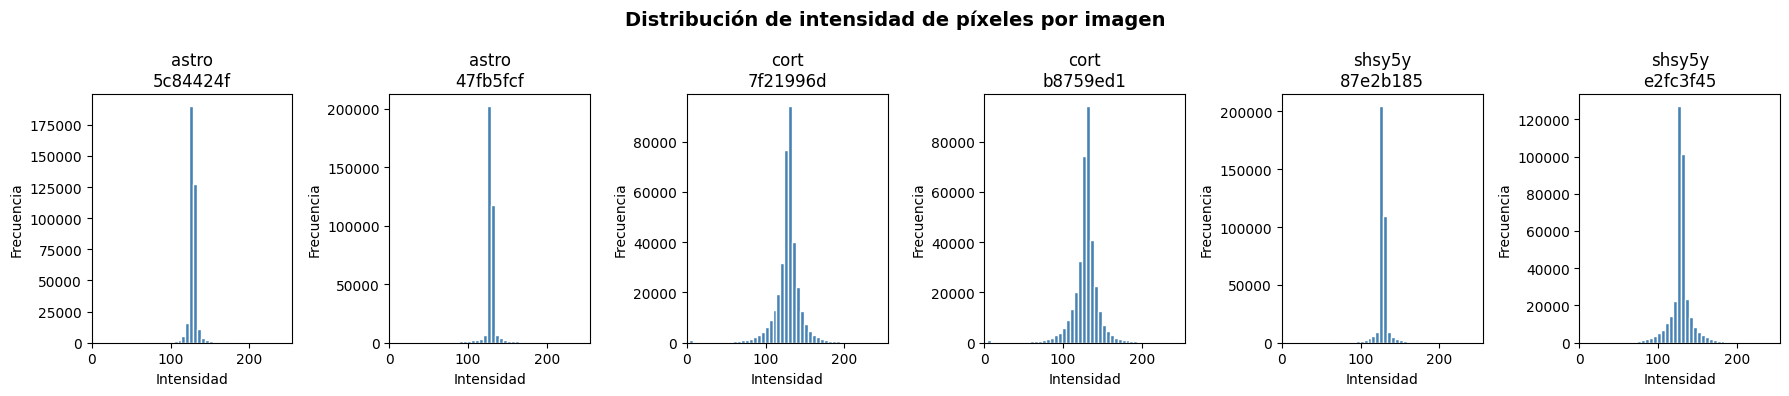

Media global    : 127.97
Desv. estándar  : 14.19
Mínimo          : 3
Máximo          : 255
Percentil 25    : 126.00
Percentil 75    : 131.00


In [16]:
sample_ids = (df_grouped.groupby('cell_type')
                        .apply(lambda x: x.sample(2, random_state=42))
                        .reset_index(drop=True)['id']
                        .values)

fig, axes = plt.subplots(1, len(sample_ids), figsize=(18, 4))

all_pixels = []

for i, img_id in enumerate(sample_ids):
    ruta = os.path.join(TRAIN_PATH, f"{img_id}.png")
    img  = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    all_pixels.append(img.flatten())
    
    axes[i].hist(img.flatten(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f"{df_grouped[df_grouped['id']==img_id]['cell_type'].values[0]}\n{img_id[:8]}")
    axes[i].set_xlabel('Intensidad')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlim(0, 255)

plt.suptitle('Distribución de intensidad de píxeles por imagen', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

all_pixels_flat = np.concatenate(all_pixels)
print(f"Media global    : {all_pixels_flat.mean():.2f}")
print(f"Desv. estándar  : {all_pixels_flat.std():.2f}")
print(f"Mínimo          : {all_pixels_flat.min()}")
print(f"Máximo          : {all_pixels_flat.max()}")
print(f"Percentil 25    : {np.percentile(all_pixels_flat, 25):.2f}")
print(f"Percentil 75    : {np.percentile(all_pixels_flat, 75):.2f}")

Las imágenes presentan una distribución de intensidad extremadamente concentrada, con una media global de 127.97, una desviación estándar de apenas 14.19 y un rango intercuartílico de solo 5 puntos (percentil 25: 126, percentil 75: 131). Esto indica que la gran mayoría de los píxeles se encuentran en valores de intensidad media, lo cual es característico de imágenes microscópicas de contraste de fase, donde el fondo y las células comparten rangos de intensidad similares y el contraste entre estructuras es bajo. Este comportamiento es consistente en los tres tipos celulares, aunque `cort` muestra una distribución ligeramente más dispersa. La baja variabilidad de intensidad confirma que la normalización estándar por división entre 255 será suficiente, pero también anticipa que la diferenciación entre células y fondo será un reto para los modelos, dado que no existe una separación clara en intensidad entre ambas regiones.

### **3.5. Visualización cualitativa**

Se visualizan 5 imágenes representativas del dataset junto con sus máscaras de segmentación superpuestas. Cada color representa una instancia celular distinta. Este análisis permite evaluar visualmente la calidad de las anotaciones, la morfología de las células y la complejidad de la tarea de segmentación.

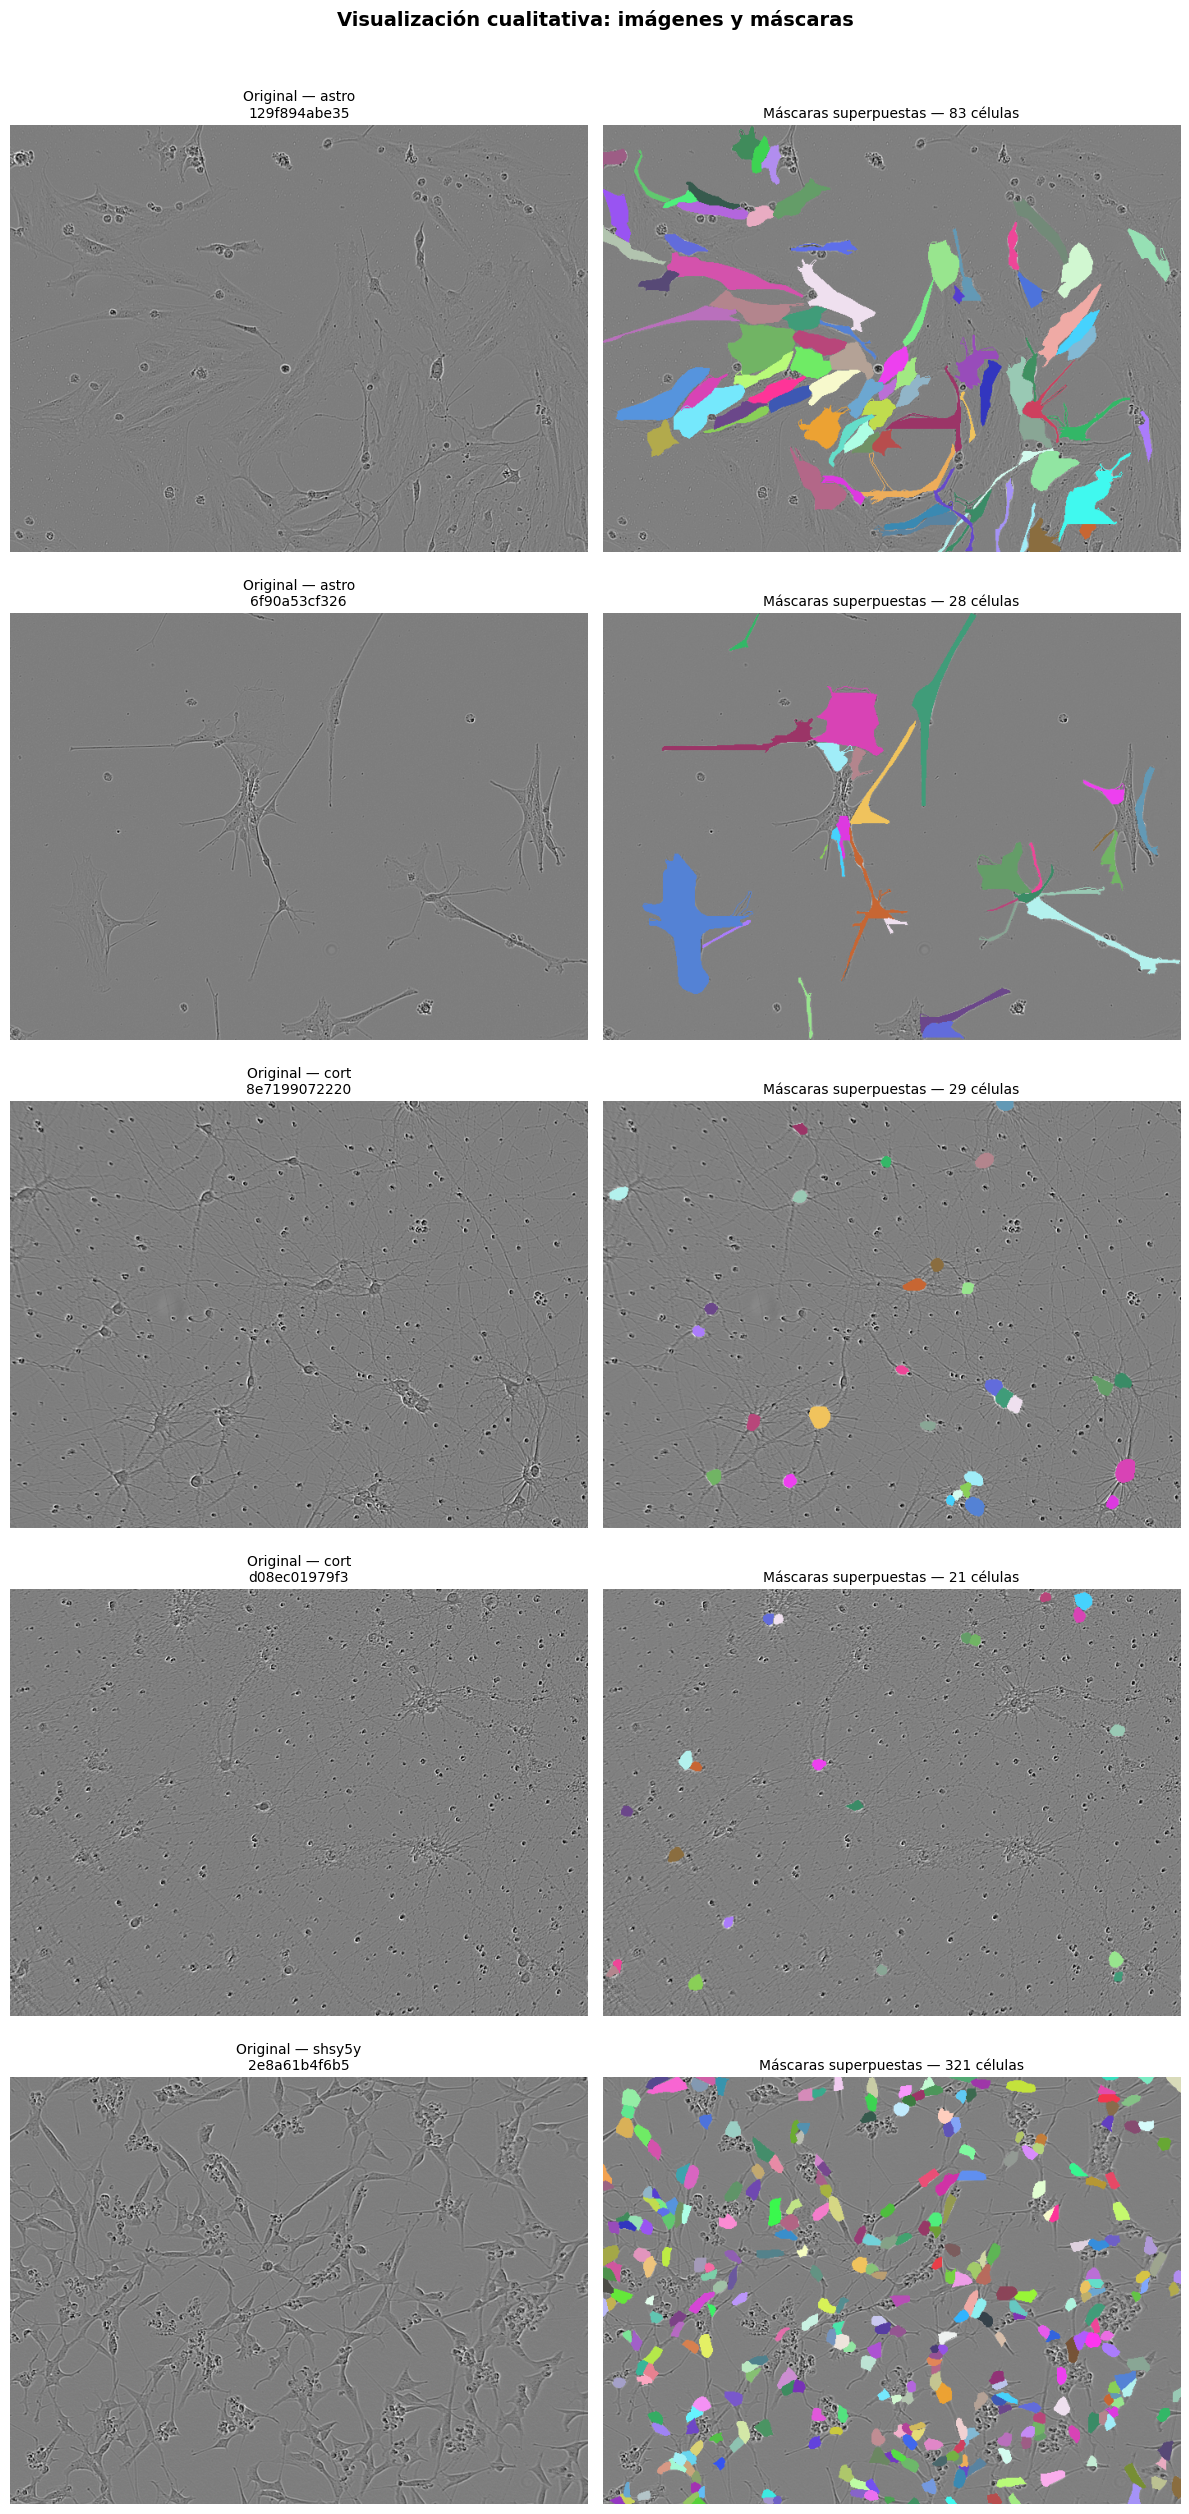

In [17]:
# Seleccionar 5 imágenes: al menos una de cada tipo celular
sample_imgs = (df_grouped.groupby('cell_type')
                         .apply(lambda x: x.sample(2, random_state=0))
                         .reset_index(drop=False)
                         .head(5))

fig, axes = plt.subplots(5, 2, figsize=(12, 25))

for i, row in sample_imgs.iterrows():
    img_id    = row['id']
    cell_type = row['cell_type']
    ruta      = row['ruta_imagen']

    # Leer imagen original en escala de grises y convertir a RGB para visualizar
    img_gray = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    img_rgb  = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

    # Obtener todas las máscaras de esta imagen
    mascaras = df[df['id'] == img_id]['annotation'].values
    h, w     = row['image_height'], row['image_width']

    # Crear capa de color para superponer máscaras
    overlay = img_rgb.copy()
    np.random.seed(42)
    for mask_rle in mascaras:
        mask  = rle_decode(mask_rle, (h, w))
        color = np.random.randint(50, 255, size=3)
        overlay[mask == 1] = color

    # Imagen original
    axes[i][0].imshow(img_gray, cmap='gray')
    axes[i][0].set_title(f"Original — {cell_type}\n{img_id[:12]}", fontsize=10)
    axes[i][0].axis('off')

    # Imagen con máscaras superpuestas
    axes[i][1].imshow(overlay)
    axes[i][1].set_title(f"Máscaras superpuestas — {row['num_masks']} células", fontsize=10)
    axes[i][1].axis('off')

plt.suptitle('Visualización cualitativa: imágenes y máscaras', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Las máscaras se ajustan correctamente a las células visibles en cada imagen. Cada tipo celular tiene una apariencia claramente distinta: las células `astro` son grandes y con formas alargadas e irregulares, lo que coincide con el mayor área promedio que encontramos antes. Las `cort` son pequeñas y redondeadas, bien separadas entre sí y fáciles de distinguir individualmente. Las `shsy5y` tienen un tamaño intermedio pero aparecen en cantidades muy altas, al punto de que en la imagen con 321 células prácticamente no queda espacio libre entre ellas, lo que las hace más difíciles de separar. En general el fondo de las imágenes tiene un tono muy parecido al de las propias células, lo que hace que a simple vista sea difícil distinguirlas sin las máscaras , por lo que este podría ser el principal reto para los modelos.

### **3.6. Conclusiones del EDA**

**¿Las imágenes son homogéneas o muy variables?**
Las imágenes son completamente homogéneas en tamaño (todas de 704 × 520 píxeles) 
y en rango de intensidad (media de 128 con desviación de apenas 14). Lo que sí 
varía considerablemente es el contenido: la densidad celular cambia mucho de una 
imagen a otra dependiendo del tipo celular.

**¿Existe desbalance en número de células?**
Sí, y en dos niveles. A nivel de tipo celular, `shsy5y` tiene cinco veces más 
instancias que `astro` y `cort`. A nivel de imagen, algunas tienen apenas 4 células 
y otras llegan a 790, con la mayoría concentrada por debajo de 46, lo que indica 
un desbalance importante en densidad.

**¿Las células son pequeñas o grandes?**
En general son pequeñas: la mediana de área es de 215 píxeles. Sin embargo `astro` 
es la excepción, con células significativamente más grandes (media de 906 píxeles) 
y formas irregulares extendidas. `cort` y `shsy5y` son mucho más pequeñas y 
compactas.

**¿Hay ruido o artefactos?**
No se observaron artefactos evidentes en las imágenes revisadas. El principal 
desafío no es el ruido sino el bajo contraste entre las células y el fondo, ya 
que ambos comparten rangos de intensidad muy similares.

## **4. Preprocesamiento**

En esta sección se hace la debida normalización, redimensionamiento, conversión de máscaras y data augmatation.

En primer lugar, se realizan las dos primeras transformaciones mencionadas anteriormente. Por su parte, la normalización consiste en dividir los valores de píxeles entre 255, llevándolos al rango [0, 1]. El redimensionamiento lleva todas las imágenes a 512 × 512 píxeles, 
tamaño estándar para modelos de segmentación. Ambas transformaciones se aplican de forma sincronizada a la imagen y a su máscara combinada.

In [18]:

print(f"Albumentations version : {A.__version__}")
print(f"Torch version          : {torch.__version__}")

Albumentations version : 2.0.8
Torch version          : 2.12.0.dev20260407+cu128


### **4.1. Normalización, Redimensionamiento, conversión de máscaras**

In [19]:
TARGET_SIZE = 256

def preprocess_image_and_mask(img_id, df, train_path, size=TARGET_SIZE):
    # Cargar imagen original en escala de grises
    ruta         = os.path.join(train_path, f"{img_id}.png")
    img_original = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    h, w         = img_original.shape

    # Construir máscara combinada sumando todas las instancias
    mascaras = df[df['id'] == img_id]['annotation'].values
    mask_combined = np.zeros((h, w), dtype=np.uint8)
    for rle in mascaras:
        mask_combined += rle_decode(rle, (h, w))
    mask_combined = np.clip(mask_combined, 0, 1)  # binaria: 0 fondo, 1 célula

    # Normalización: llevar píxeles al rango [0, 1]
    img_norm = img_original / 255.0

    # Redimensionamiento a TARGET_SIZE x TARGET_SIZE
    img_resized  = cv2.resize(img_norm, (size, size))
    mask_resized = cv2.resize(mask_combined.astype(np.float32), (size, size),
                              interpolation=cv2.INTER_NEAREST)

    return img_original, img_resized, mask_combined, mask_resized


Esta función `preprocess_image_and_mask` recibe el ID de una imagen y realiza todo el pipeline de preprocesamiento en un solo paso. Primero carga la imagen original en escala de grises, luego combina todas sus máscaras RLE individuales en una única máscara binaria donde 1 representa célula y 0 representa fondo. Después normaliza la imagen dividiendo entre 255 y redimensiona tanto la imagen como la máscara a 256 × 256 píxeles. Retorna las cuatro versiones (original y procesada, tanto de imagen como de máscara) para poder compararlas visualmente y confirmar que el preprocesamiento es correcto antes de pasarlas al modelo.

In [20]:
# Probar con una imagen de cada tipo celular
sample_ids = df_grouped.groupby('cell_type').apply(
    lambda x: x.sample(1, random_state=42)
).reset_index(drop=True)['id'].values

print(f"Imágenes de prueba: {sample_ids}")

Imágenes de prueba: <StringArray>
['5c84424f601c', '7f21996da2e6', '87e2b185e074']
Length: 3, dtype: str


Ahora, se visualizan lado a lado la imagen original, la imagen preprocesada, la máscara binaria original y la máscara redimensionada, para verificar que el pipeline de preprocesamiento conserva correctamente la información relevante.

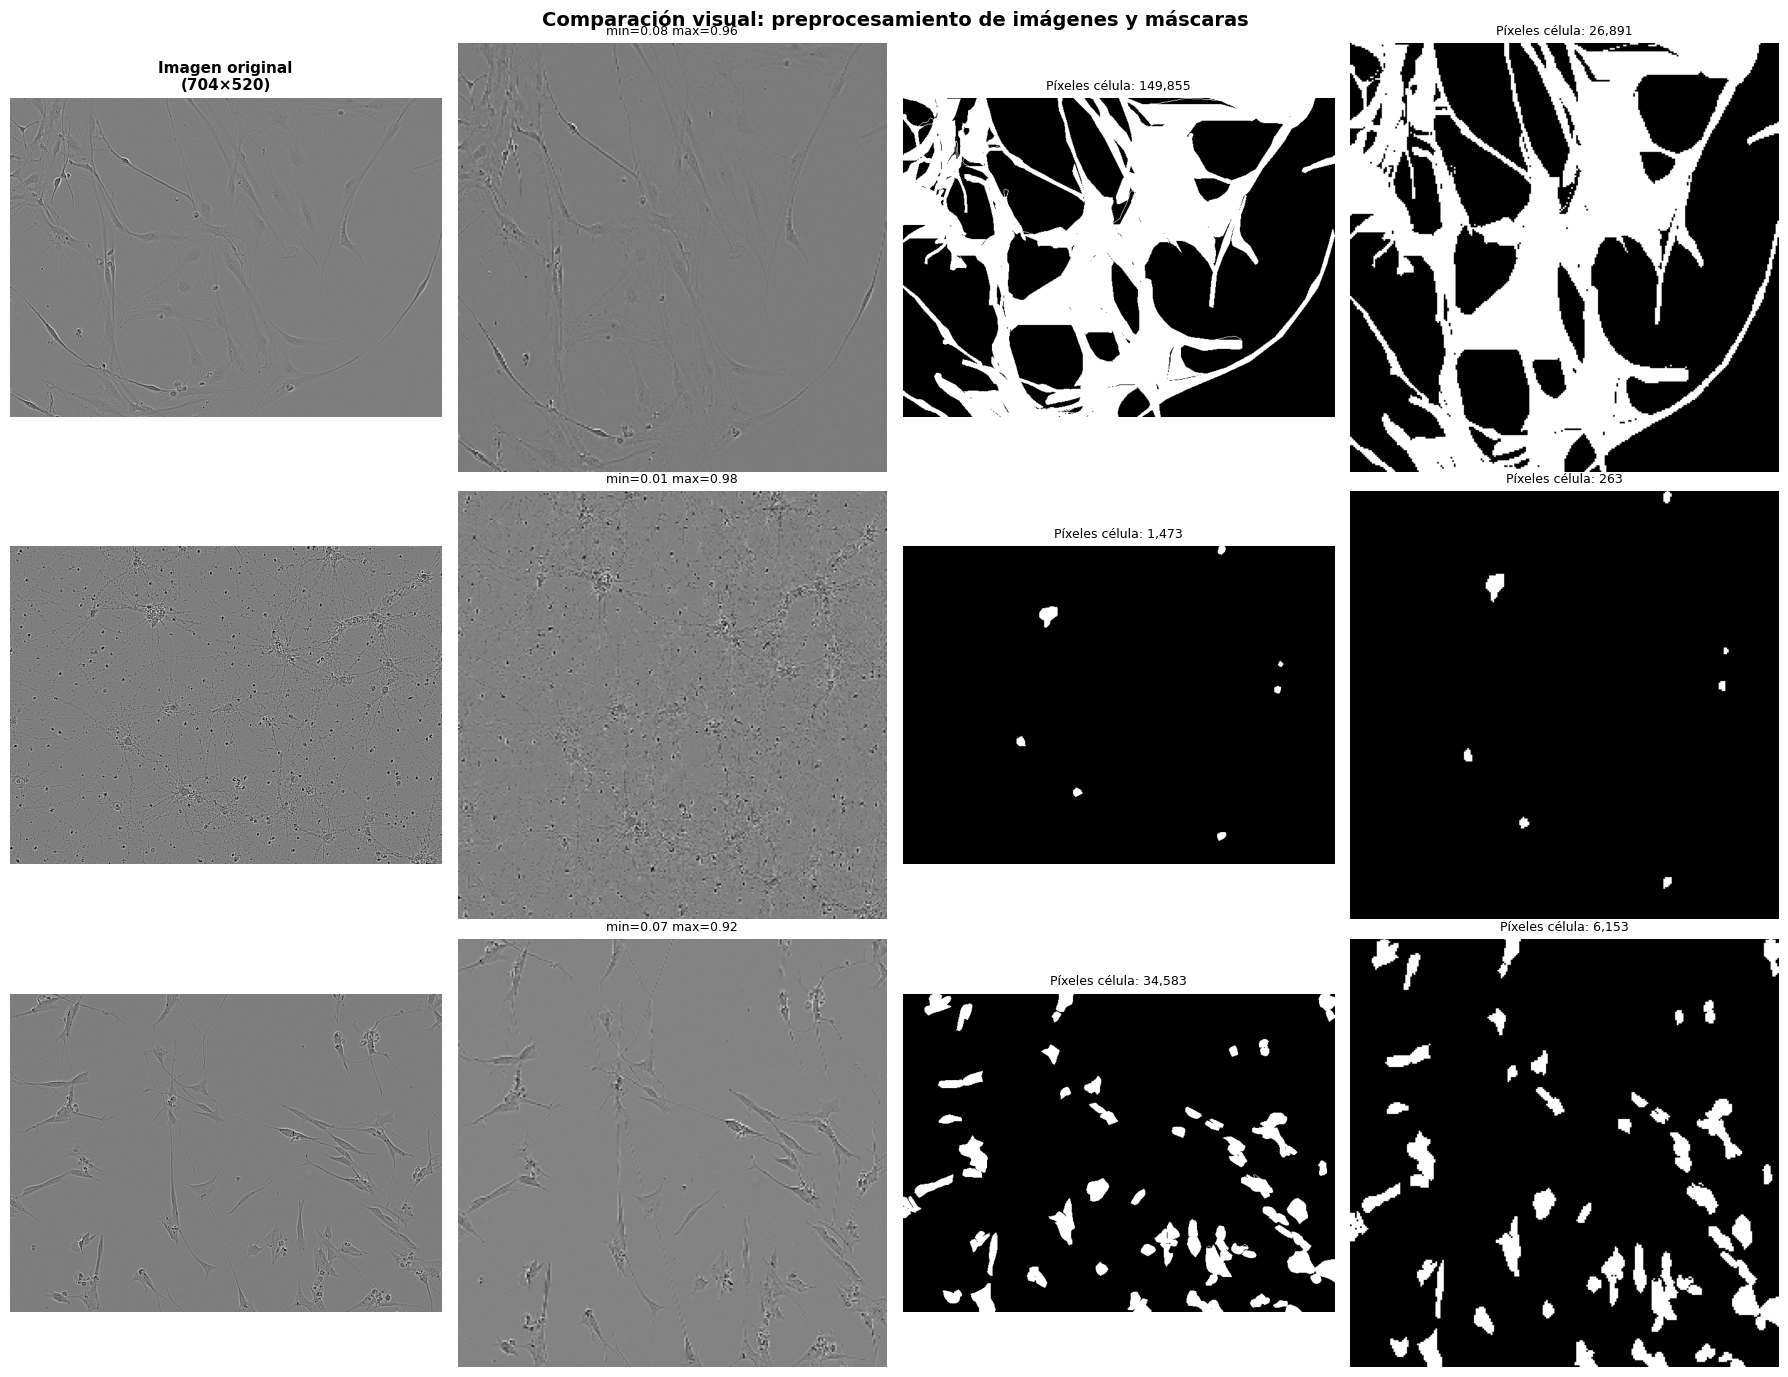

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(18, 14))

col_titles = ['Imagen original\n(704×520)', 
              'Imagen procesada\n(512×512, normalizada)',
              'Máscara original\n(binaria)', 
              'Máscara procesada\n(512×512)']

for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=11, fontweight='bold')

for i, img_id in enumerate(sample_ids):
    img_orig, img_proc, mask_orig, mask_proc = preprocess_image_and_mask(
        img_id, df, TRAIN_PATH
    )
    cell_type = df_grouped[df_grouped['id'] == img_id]['cell_type'].values[0]
    num_cells = df_grouped[df_grouped['id'] == img_id]['num_masks'].values[0]

    # Imagen original
    axes[i][0].imshow(img_orig, cmap='gray')
    axes[i][0].set_ylabel(f"{cell_type}\n{num_cells} células", fontsize=10)
    axes[i][0].axis('off')

    # Imagen procesada
    axes[i][1].imshow(img_proc, cmap='gray')
    axes[i][1].set_title(f"min={img_proc.min():.2f} max={img_proc.max():.2f}", 
                         fontsize=9)
    axes[i][1].axis('off')

    # Máscara original
    axes[i][2].imshow(mask_orig, cmap='gray')
    axes[i][2].set_title(f"Píxeles célula: {mask_orig.sum():,}", fontsize=9)
    axes[i][2].axis('off')

    # Máscara procesada
    axes[i][3].imshow(mask_proc, cmap='gray')
    axes[i][3].set_title(f"Píxeles célula: {mask_proc.sum():,.0f}", fontsize=9)
    axes[i][3].axis('off')

plt.suptitle('Comparación visual: preprocesamiento de imágenes y máscaras', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Se puede observar que las imágenes procesadas conservan toda la información visual de las originales, con valores confirmados en el rango [0, 1] como se esperaba. Las máscaras binarias muestran en blanco las regiones celulares y en negro el fondo, y se mantienen coherentes tras el redimensionamiento a 256 × 256. Se confirman además las diferencias morfológicas entre tipos celulares: `astro` ocupa una proporción grande de la imagen, `cort` tiene células muy pequeñas y dispersas, y `shsy5y` presenta una densidad intermedia pero con instancias de tamaño considerable). El redimensionamiento reduce ligeramente el conteo de píxeles celulares pero preserva la estructura espacial de las máscaras sin distorsiones visibles.

### **4.2. Data augmentation**

El aumento de datos aplica transformaciones aleatorias a las imágenes durante el entrenamiento para que el modelo vea mayor variedad de ejemplos sin necesidad de recolectar más datos. Las transformaciones se aplican de forma sincronizada a la imagen y a su máscara para mantener la correspondencia entre ambas. Las transformaciones aplicadas son: rotaciones, flips horizontales y verticales, y zoom aleatorio.

/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


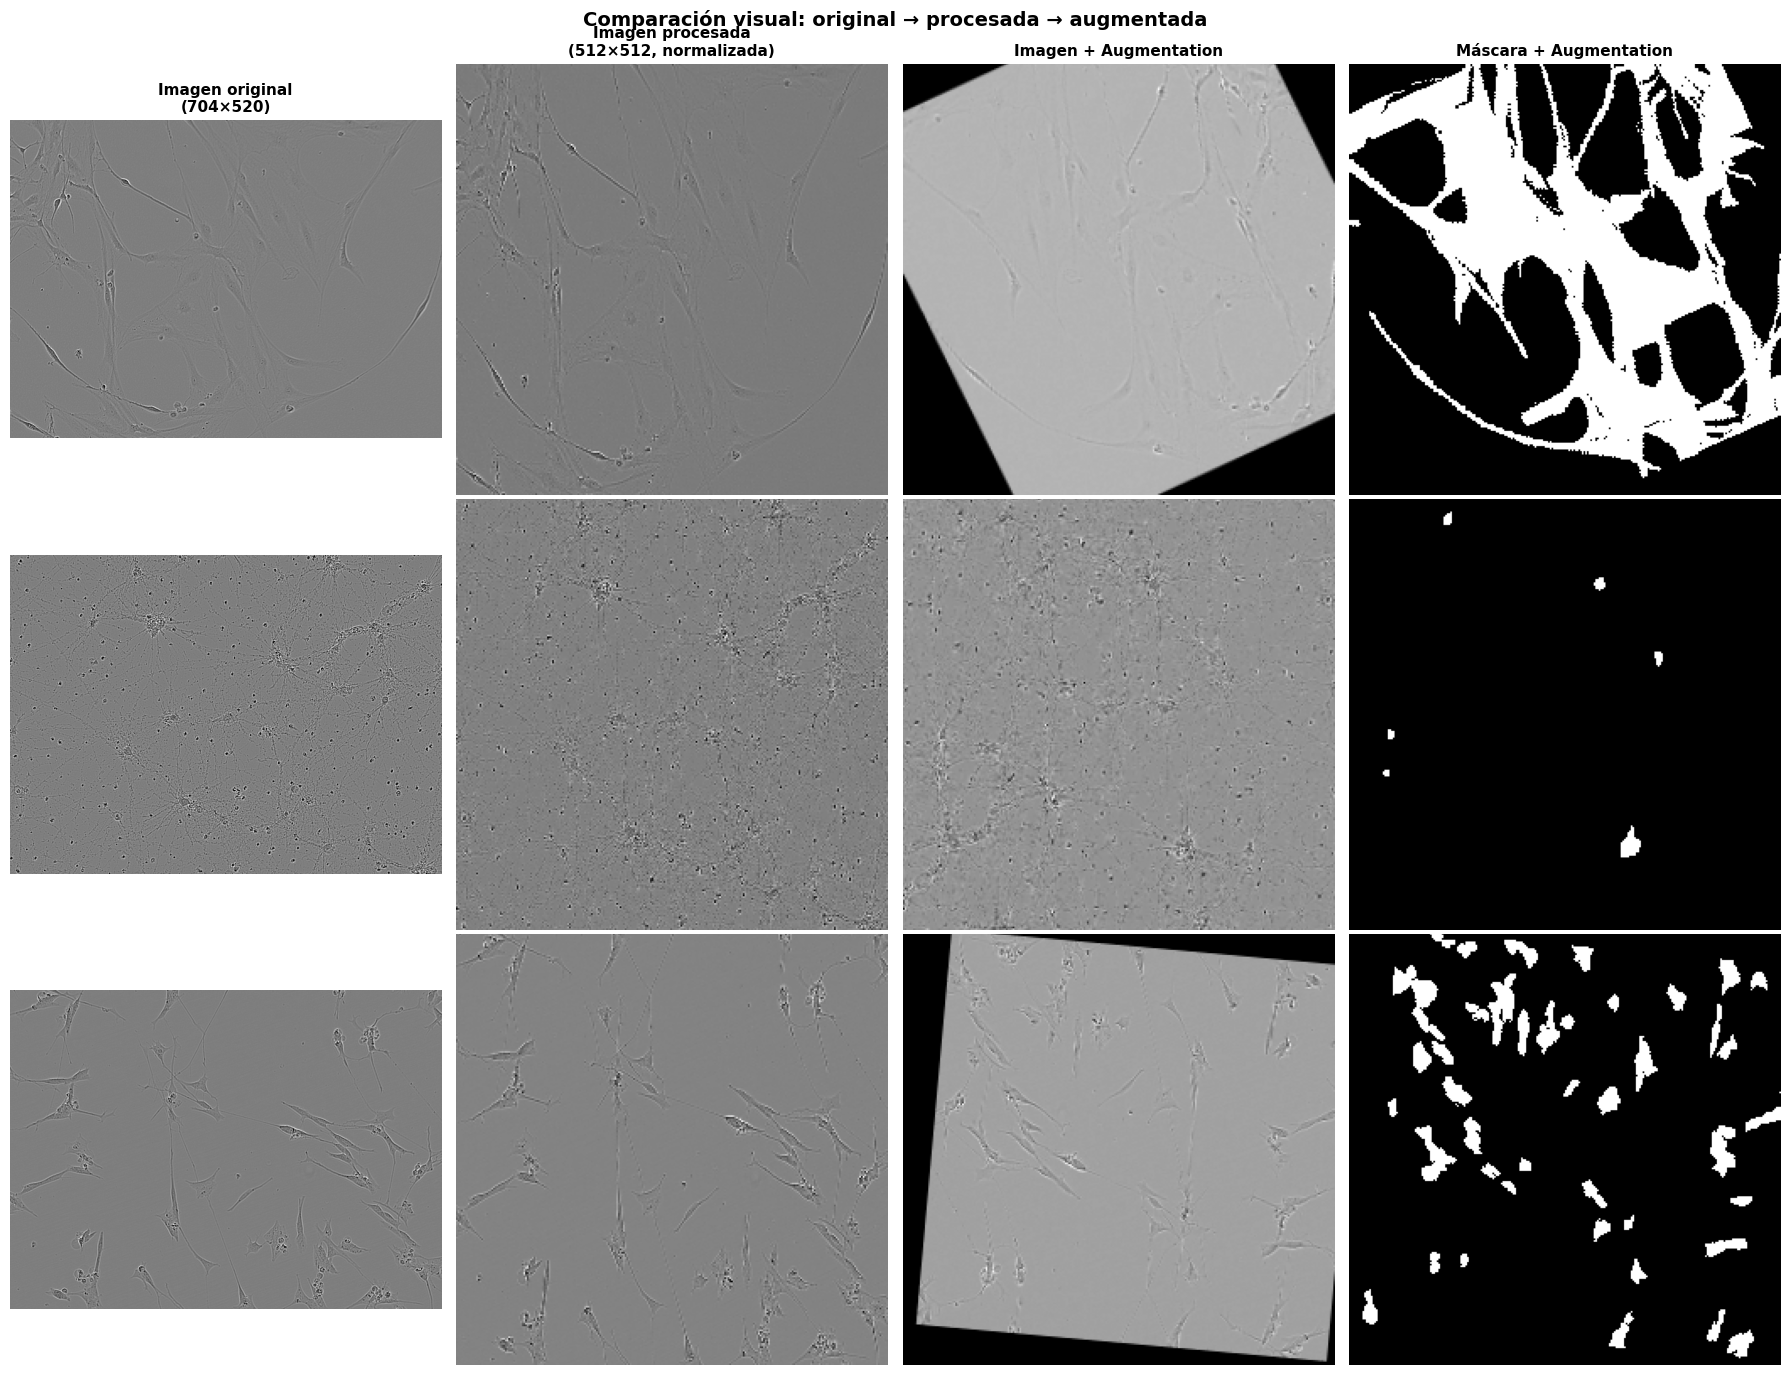

In [22]:
# Pipeline de data augmentation con albumentations
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, 
                       rotate_limit=45, p=0.5),
    A.RandomResizedCrop(size=(TARGET_SIZE, TARGET_SIZE), 
                    scale=(0.8, 1.0), p=0.5),
])

def apply_augmentation(img, mask):
    img_uint8  = (img * 255).astype(np.uint8)
    mask_uint8 = (mask * 255).astype(np.uint8)

    augmented     = augmentation_pipeline(image=img_uint8, mask=mask_uint8)
    img_aug       = augmented['image'].astype(np.float32) / 255.0
    mask_aug      = augmented['mask'].astype(np.float32) / 255.0

    return img_aug, mask_aug

# Probar con las mismas 3 imágenes de muestra
fig, axes = plt.subplots(3, 4, figsize=(18, 14))

col_titles = ['Imagen original\n(704×520)', 
              'Imagen procesada\n(512×512, normalizada)',
              'Imagen + Augmentation',
              'Máscara + Augmentation']

for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=11, fontweight='bold')

for i, img_id in enumerate(sample_ids):
    img_orig, img_proc, mask_orig, mask_proc = preprocess_image_and_mask(
        img_id, df, TRAIN_PATH
    )
    img_aug, mask_aug = apply_augmentation(img_proc, mask_proc)

    cell_type = df_grouped[df_grouped['id'] == img_id]['cell_type'].values[0]
    num_cells = df_grouped[df_grouped['id'] == img_id]['num_masks'].values[0]

    # Imagen original
    axes[i][0].imshow(img_orig, cmap='gray')
    axes[i][0].set_ylabel(f"{cell_type}\n{num_cells} células", fontsize=10)
    axes[i][0].axis('off')

    # Imagen procesada
    axes[i][1].imshow(img_proc, cmap='gray')
    axes[i][1].axis('off')

    # Imagen augmentada
    axes[i][2].imshow(img_aug, cmap='gray')
    axes[i][2].axis('off')

    # Máscara augmentada
    axes[i][3].imshow(mask_aug, cmap='gray')
    axes[i][3].axis('off')

plt.suptitle('Comparación visual: original → procesada → augmentada', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Note que el pipeline completo funciona correctamente en sus tres etapas. La normalización lleva los valores de píxeles al rango [0, 1] sin alterar la información visual. El redimensionamiento a 512 × 512 conserva las estructuras celulares sin distorsiones apreciables. El data augmentation aplica transformaciones aleatorias que en algunas imágenes son sutiles y en otras más evidentes, lo cual es el comportamiento esperado dado que cada transformación tiene una probabilidad de activarse del 50%. Lo más importante es que las máscaras de la última columna siempre corresponden espacialmente a su imagen augmentada, confirmando que la sincronización entre imagen y máscara funciona correctamente.

## **Exportación de datos preprocesados**

Se guardan los dataframes y configuraciones necesarias para el notebook de 
modelación, evitando repetir el proceso de carga y preprocesamiento.

In [23]:
# Carpeta de datos procesados
PROCESSED_PATH = r"/home/moon/DEEP/MP3/data/processed"
os.makedirs(PROCESSED_PATH, exist_ok=True)

# Guardar dataframes
df.to_csv(os.path.join(PROCESSED_PATH, "df_annotations.csv"), index=False)
df_grouped.to_csv(os.path.join(PROCESSED_PATH, "df_grouped.csv"), index=False)

# Guardar configuración general
config = {
    "BASE_PATH"  : BASE_PATH,
    "TRAIN_PATH" : TRAIN_PATH,
    "CSV_PATH"   : CSV_PATH,
    "TARGET_SIZE": TARGET_SIZE,
}

with open(os.path.join(PROCESSED_PATH, "config.pkl"), "wb") as f:
    pickle.dump(config, f)

print("Archivos guardados:")
for f in os.listdir(PROCESSED_PATH):
    print(f"  {f}")

Archivos guardados:
  config.pkl
  df_grouped.csv
  df_annotations.csv
